In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
import time

In [3]:
print("Fetching MNIST dataset")
mnist = fetch_openml('mnist_784', version=1, cache=True, parser='auto')

X = mnist.data.values.astype('float32') / 255.0
y = mnist.target.values.astype('int')

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=60000, test_size=10000, random_state=42)
print(f"{X_train.shape[0]} train samples, {X_test.shape[0]} test samples.\n")

Fetching MNIST dataset
60000 train samples, 10000 test samples.



In [4]:
d = 5
T_exp = 2
epochs = int(T_exp)

M_x_list = [] # Stores mistake features for each class
M_y_list = [] # Stores mistake labels for each class
C_vecs = []   # Stores survival times

print(f"Starting Kernel Training (d={d}, T={T_exp})")
start_train_time = time.time()

X_train = np.ascontiguousarray(X_train, dtype=np.float32)
for c in range(10):
    c_start_time = time.time()
    y_bin = np.where(y_train == c, 1, -1)

    # Preallocate mistakes array to avoid reconstruction per mistake
    max_mistakes = 10000
    M_x_arr = np.empty((max_mistakes, 784), dtype=np.float32)
    M_y_arr = np.empty(max_mistakes, dtype=np.float32)
    mistake_count = 0
    
    C = [0]
    
    for epoch in range(epochs):
        for i in range(len(X_train)):
            x_i = X_train[i]
            y_i = y_bin[i]
            
            if mistake_count == 0:
                v_dot_x = 0.0
            else:
                # Vectorized kernel calculation against all historical mistakes
                v_dot_x = np.dot(M_y_arr[:mistake_count], (np.dot(M_x_arr[:mistake_count], x_i) + 1.0) ** d)
                
            y_hat = 1 if v_dot_x >= 0 else -1
            
            if y_hat == y_i:
                C[-1] += 1
            else:
                M_x_arr[mistake_count] = x_i
                M_y_arr[mistake_count] = y_i
                mistake_count += 1
                C.append(1)
                
    # Save the history matrices for this class
    final_M_x = M_x_arr[:mistake_count].copy()
    final_M_y = M_y_arr[:mistake_count].copy()

    M_x_list.append(final_M_x)
    M_y_list.append(final_M_y)
        
    C_vecs.append(np.array(C))
    print(f"  Class {c} completed in {time.time() - c_start_time:.1f}s | Total mistakes: {mistake_count}")

print(f"Total time: {time.time() - start_train_time:.1f}s\n")

Starting Kernel Training (d=5, T=2)
  Class 0 completed in 4.6s | Total mistakes: 609
  Class 1 completed in 2.8s | Total mistakes: 505
  Class 2 completed in 3.2s | Total mistakes: 1018
  Class 3 completed in 3.2s | Total mistakes: 1243
  Class 4 completed in 3.5s | Total mistakes: 880
  Class 5 completed in 3.5s | Total mistakes: 1072
  Class 6 completed in 2.9s | Total mistakes: 715
  Class 7 completed in 3.2s | Total mistakes: 977
  Class 8 completed in 4.1s | Total mistakes: 1489
  Class 9 completed in 5.6s | Total mistakes: 1475
Total time: 36.5s



In [5]:
from threadpoolctl import threadpool_limits
from joblib import Parallel, delayed

# RUN CLASS TRAINING IN PARALLEL FOR FUN

d = 4
T_exp = 2
epochs = int(T_exp)

def train_class(c, X_train, y_train, d, epochs):
    c_start_time = time.time()
    y_bin = np.where(y_train == c, 1, -1)

    # Preallocate mistakes array to avoid reconstruction per mistake
    max_mistakes = 10000
    M_x_arr = np.empty((max_mistakes, 784), dtype=np.float32)
    M_y_arr = np.empty(max_mistakes, dtype=np.float32)
    mistake_count = 0
    
    C = [0]
    
    for epoch in range(epochs):
        for i in range(len(X_train)):
            x_i = X_train[i]
            y_i = y_bin[i]
            
            if mistake_count == 0:
                v_dot_x = 0.0
            else:
                # Vectorized kernel calculation against all historical mistakes
                v_dot_x = M_y_arr[:mistake_count] @ ((M_x_arr[:mistake_count] @ x_i + 1.0) ** d)
                
            y_hat = 1 if v_dot_x >= 0 else -1
            
            if y_hat == y_i:
                C[-1] += 1
            else:
                M_x_arr[mistake_count] = x_i
                M_y_arr[mistake_count] = y_i
                mistake_count += 1
                C.append(1)
                
    # Free unused allocated memory via .copy()
    final_M_x = M_x_arr[:mistake_count].copy()
    final_M_y = M_y_arr[:mistake_count].copy()
    
    return (
        c,
        final_M_x,
        final_M_y,
        np.array(C),
        mistake_count,
        time.time() - c_start_time
    )

def train_voted_perceptron(X_train, y_train, d, epochs):
    print(f"Starting Kernel Training (d={d}, T={epochs})")
    start_train_time = time.time()
    
    X_train = np.ascontiguousarray(X_train, dtype=np.float32)
    results = Parallel(n_jobs=10)(
        delayed(train_class)(c, X_train, y_train, d, epochs)
        for c in range(10)
    )
    
    # Get back class ordering (0-9)
    results.sort(key=lambda x: x[0])
    
    M_x_list = []
    M_y_list = []
    C_vecs = []
    
    for c, M_x, M_y, C, mistake_count, elapsed in results:
        M_x_list.append(M_x)
        M_y_list.append(M_y)
        C_vecs.append(C)
        print(f"  Class {c} completed in {elapsed:.1f}s | Total mistakes: {mistake_count}")
    
    print(f"Total time: {time.time() - start_train_time:.1f}s\n")

    return (
        M_x_list,
        M_y_list,
        C_vecs
    )

In [8]:
def evaluate(X_test, M_x_list, M_y_list, C_vecs, d):
    print("Evaluating")
    start_eval_time = time.time()
    
    batch_size = 1000
    y_pred_all = np.zeros(len(X_test))
    conf_method = np.zeros(len(X_test))
    
    for i in range(0, len(X_test), batch_size):
        X_batch = X_test[i:i+batch_size]
        batch_scores = np.zeros((len(X_batch), 10))
        batch_signs_list = []
        
        for c in range(10):
            if len(M_x_list[c]) > 0:
                K_matrix = (np.dot(X_batch, M_x_list[c].T) + 1.0) ** d
                K_weighted = K_matrix * M_y_list[c]
                
                H_vals = np.hstack([np.zeros((len(X_batch), 1)), np.cumsum(K_weighted, axis=1)])
                signs = np.where(H_vals >= 0, 1, -1)
                
                batch_signs_list.append(signs)
                batch_scores[:, c] = np.dot(signs, C_vecs[c])
            else:
                batch_signs_list.append(np.ones((len(X_batch), 1)))
                batch_scores[:, c] = np.ones(len(X_batch)) * C_vecs[c][0]
                
        y_pred_batch = np.argmax(batch_scores, axis=1)
        y_pred_all[i:i+batch_size] = y_pred_batch
        
        for j in range(len(X_batch)):
            winner = y_pred_batch[j]
            global_j = i + j
            
            # --- Unbroken Streak ---
            signs_winner = batch_signs_list[winner][j]
            last_vote = signs_winner[-1]
            reversed_signs = signs_winner[::-1]
            matches = (reversed_signs == last_vote)
            streak = len(signs_winner) if np.all(matches) else np.argmin(matches)
            conf_method[global_j] = streak
    
        print(f"  Processed batch {i} to {i+len(X_batch)}...")
    
    print(f"Evaluation Complete! Total time: {time.time() - start_eval_time:.1f}s\n")

    return y_pred_all, conf_method

Generating Plots
Starting Kernel Training (d=1, T=1)
  Class 0 completed in 6.3s | Total mistakes: 1041
  Class 1 completed in 6.0s | Total mistakes: 964
  Class 2 completed in 13.5s | Total mistakes: 2335
  Class 3 completed in 15.3s | Total mistakes: 2690
  Class 4 completed in 11.0s | Total mistakes: 2017
  Class 5 completed in 16.5s | Total mistakes: 3019
  Class 6 completed in 9.3s | Total mistakes: 1450
  Class 7 completed in 9.4s | Total mistakes: 1703
  Class 8 completed in 22.7s | Total mistakes: 4215
  Class 9 completed in 21.5s | Total mistakes: 3772
Total time: 23.0s

Evaluating
  Processed batch 0 to 1000...
  Processed batch 1000 to 2000...
  Processed batch 2000 to 3000...
  Processed batch 3000 to 4000...
  Processed batch 4000 to 5000...
  Processed batch 5000 to 6000...
  Processed batch 6000 to 7000...
  Processed batch 7000 to 8000...
  Processed batch 8000 to 9000...
  Processed batch 9000 to 10000...
Evaluation Complete! Total time: 4.5s

Starting Kernel Training 

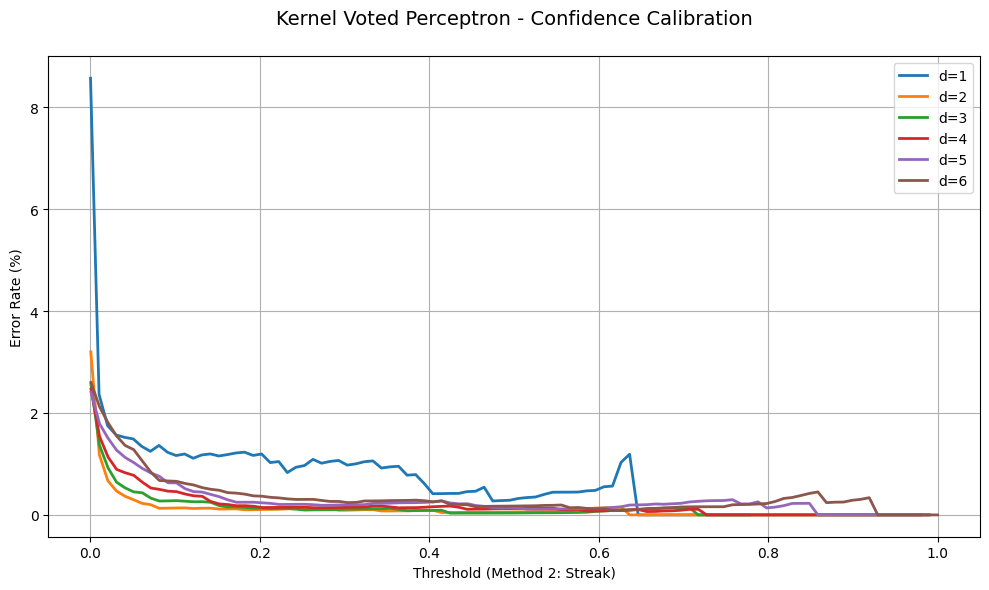

In [11]:
def get_error_rates(confidences, mistakes):
    thresholds = np.linspace(np.min(confidences), np.max(confidences), 100)
    error_rates = []
    
    for t in thresholds:
        keep_mask = confidences >= t
        retained = np.sum(keep_mask)
        
        # Enforce minimum 20 samples to prevent crazy random spikes at the end
        if retained > 20: 
            error_rate = np.mean(mistakes[keep_mask]) * 100
            error_rates.append(error_rate)
        else:
            error_rates.append(np.nan)
            
    return thresholds, error_rates

print("Generating Plots")


# Plot
fig, ax2 = plt.subplots(figsize=(10, 6))
ax2.grid(True)
ax2.set_xlabel('Threshold (Method 2: Streak)')
ax2.set_ylabel('Error Rate (%)')
ax2.set_title('Unbroken Streak')
plt.title(f"Kernel Voted Perceptron - Confidence Calibration", fontsize=14, y=1.05)

EPOCHS = 1
for d in range(1, 7):
    M_x_list, M_y_list, C_vecs = train_voted_perceptron(X_train, y_train, d, EPOCHS)
    y_pred_all, conf_method = evaluate(X_test, M_x_list, M_y_list, C_vecs, d)
    mistakes_mask = (y_pred_all != y_test)
    thres, err = get_error_rates(conf_method, mistakes_mask)

    ax2.plot(thres / max(thres), err, '-', linewidth=2, label=f'd={d}')

ax2.legend()
plt.tight_layout()
plt.show()
    
# plt.savefig('streak_conf_voted_perceptron_d6.png', dpi=300, bbox_inches='tight')